# Preparing newt Multiome data for Cell Ranger ARC

**Goal:** understand exactly what `cellranger-arc count` expects as input, work out how your
sequencing data differs from that, and build the transformations that close the gap.

This notebook is designed to run *today*, before your external drive is plugged in. It
generates a small synthetic, correctly-formatted Multiome dataset so every cell has something
to chew on. When your real data is available you point `DATA_DIR` at it and re-run.

### How to read this notebook

Each section answers a *why* before it shows a *how*. The order matters:

| § | Question |
|---|---|
| 1 | Where does FASTQ prep sit in the pipeline, and why is it fiddly? |
| 2 | What does a Multiome read actually contain? |
| 3 | What filenames does Cell Ranger ARC insist on, and why? |
| 4 | Demo data so this notebook runs now |
| 5 | How do I inspect a FASTQ? |
| 6 | Do my read lengths match the spec? |
| 7 | Are my barcodes where I think they are? *(the decisive test)* |
| 8 | Visualising the checks |
| 9 | Writing `libraries.csv` |
| 10 | A single validation function + what comes next |

## 1. The big picture

A 10x run normally flows like this:

```
Illumina sequencer
      |
      v
  BCL files            <-- raw per-cycle intensities, one dir per flowcell
      |
      |  bcl2fastq / cellranger-arc mkfastq      <-- demultiplexing
      v
  FASTQ files          <-- ****  you need to land exactly here  ****
      |
      |  cellranger-arc count
      v
  filtered_feature_bc_matrix/ , atac_fragments.tsv.gz , per_barcode_metrics.csv , web_summary.html
```

`cellranger-arc count` is deliberately rigid about its entry point. It does **not** take
"some FASTQ files" — it takes a *directory* which it scans for files matching a naming
pattern, and it infers the meaning of each file (genomic read? barcode? UMI?) purely from
the `R1`/`R2`/`R3`/`I1`/`I2` token in the filename.

That design is the source of nearly every "it worked for them but not for me" problem:

* Data from **SRA** loses the original filenames. `fasterq-dump` gives you `SRR1234_1.fastq`,
  `_2`, `_3` — and the mapping from those numbers back to R1/R2/R3 is *not* guaranteed and
  often not documented.
* Data from a **sequencing core** may be demultiplexed with the barcode read left at its full
  sequenced length rather than trimmed to the barcode.
* Data delivered as a **single interleaved file** has to be split.
* A core that has never run Multiome may have used a **standard ATAC or standard GEX recipe**,
  producing reads of the wrong length.

None of these are hard to fix — but you have to *know which one you have*. That is what
sections 5–7 are for. Section 7 in particular is the one that settles the question
empirically rather than by reading documentation.

> **A note on the newt.** Everything in this notebook concerns the *reads*, which are
> species-independent — a barcode is a barcode. The species-specific work is the
> **reference**, which you build separately with `cellranger-arc mkref` from your genome
> FASTA + GTF. That is a substantial job in its own right for a large amphibian genome, and
> it is deliberately out of scope here. Get the reads validated first.

In [1]:
from __future__ import annotations

import gzip
import re
from collections import Counter
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ---------------------------------------------------------------- configuration
# The Cell Ranger ARC install (used for its bundled barcode whitelists).
ARC_HOME = Path("/home/supermepsipax/Code/cellranger/cellranger-arc-2.2.0")

# Point this at your external drive when it is mounted, e.g.
#   DATA_DIR = Path("/media/supermepsipax/newtdrive/fastqs")
# Until then it defaults to the synthetic demo data built in section 4.
PROJECT = Path("/home/supermepsipax/Code/cellranger")
DATA_DIR = PROJECT / "data" / "demo"

pd.set_option("display.max_colwidth", 100)

assert ARC_HOME.is_dir(), f"Cell Ranger ARC not found at {ARC_HOME}"
print("ARC install :", ARC_HOME)
print("Data dir    :", DATA_DIR, "(exists)" if DATA_DIR.exists() else "(will be created in §4)")

ARC install : /home/supermepsipax/Code/cellranger/cellranger-arc-2.2.0
Data dir    : /home/supermepsipax/Code/cellranger/data/demo (will be created in §4)


## 2. What is actually in a Multiome read?

A Multiome experiment produces **two separate libraries** from the *same* nuclei — an ATAC
library and a Gene Expression library. They are sequenced separately, have different read
structures, and even use **different barcode sequences** for the same cell (more on that in
§7). Cell Ranger ARC's job is to link them back together.

### Gene Expression library

| Read | Length | Contents |
|------|--------|----------|
| R1   | 28 bp  | 16 bp cell barcode + 12 bp UMI |
| R2   | 90 bp  | cDNA insert — the bit that actually gets aligned to the transcriptome |
| I1   | 10 bp  | i7 sample index |
| I2   | 10 bp  | i5 sample index |

So in GEX, **R1 carries no biological sequence at all** — it is pure barcode+UMI. All the
transcript information is in R2.

### ATAC library

| Read | Length | Contents |
|------|--------|----------|
| R1   | 50 bp  | transposed genomic DNA |
| R2   | 16 bp  | **16 bp cell barcode** (sequenced as the i5 index, 24 cycles) |
| R3   | 49 bp  | transposed genomic DNA (the mate of R1) |
| I1   | 8 bp   | i7 sample index |

The ATAC layout is the one that trips people up. Two things are unusual:

1. **The barcode is in the i5 index position, not in R1.** The sequencer is given a 24-cycle
   i5 recipe, but the barcode itself is 16 bp. Demultiplexing is expected to emit a **16 bp**
   R2. If your R2 is 24 bp, the barcode is in there but padded — §7 finds out which end.
2. **There are three "real" reads (R1, R2, R3), not two.** ATAC is paired-end genomic
   (R1 + R3) *plus* a barcode read (R2) promoted out of the index position. Cell Ranger ARC
   also accepts the equivalent naming where the barcode stays as `I2` and the second genomic
   read is `R2`.

The consequence: **`R2` means completely different things in the two libraries.** In GEX it
is a 90 bp cDNA insert; in ATAC it is a 16 bp barcode. If you mix these up, Cell Ranger ARC
will either error out or — worse — run and produce nonsense.

In [2]:
# Encode the spec as data so later cells can check against it rather than hardcoding.

@dataclass(frozen=True)
class ReadSpec:
    length: int
    contents: str
    required: bool = True

GEX_SPEC = {
    "R1": ReadSpec(28, "16 bp cell barcode + 12 bp UMI"),
    "R2": ReadSpec(90, "cDNA insert"),
    "I1": ReadSpec(10, "i7 sample index", required=False),
    "I2": ReadSpec(10, "i5 sample index", required=False),
}

ATAC_SPEC = {
    "R1": ReadSpec(50, "genomic DNA"),
    "R2": ReadSpec(16, "16 bp cell barcode (from i5)"),
    "R3": ReadSpec(49, "genomic DNA (mate of R1)"),
    "I1": ReadSpec(8, "i7 sample index", required=False),
}

SPECS = {"Gene Expression": GEX_SPEC, "Chromatin Accessibility": ATAC_SPEC}

def spec_table(spec: dict[str, ReadSpec]) -> pd.DataFrame:
    return pd.DataFrame(
        [(r, s.length, s.contents, "required" if s.required else "optional")
         for r, s in spec.items()],
        columns=["read", "expected_bp", "contents", "status"],
    ).set_index("read")

for name, spec in SPECS.items():
    print(f"\n=== {name} ===")
    display(spec_table(spec))


=== Gene Expression ===


,expected_bp,contents,status
read,,,
R1,28,16 bp cell barcode + 12 bp UMI,required
R2,90,cDNA insert,required
I1,10,i7 sample index,optional
I2,10,i5 sample index,optional



=== Chromatin Accessibility ===


,expected_bp,contents,status
read,,,
R1,50,genomic DNA,required
R2,16,16 bp cell barcode (from i5),required
R3,49,genomic DNA (mate of R1),required
I1,8,i7 sample index,optional


## 3. The filename convention

Cell Ranger ARC locates its inputs by **globbing a directory**, so the filename *is* the
metadata. The pattern is inherited from `bcl2fastq`:

```
{sample}_S{n}_L{lane}_{read}_001.fastq.gz
   |      |     |       |     |
   |      |     |       |     +-- chunk number, essentially always 001
   |      |     |       +-------- R1 | R2 | R3 | I1 | I2
   |      |     +---------------- lane, 3 digits, e.g. L001  (may be omitted entirely)
   |      +---------------------- sample *number* within the flowcell, e.g. S1
   +----------------------------- sample *name* — this is what libraries.csv matches on
```

Real examples straight from the 10x docs:

```
Sample-GA-A1_S1_L001_I1_001.fastq.gz
Sample-GA-A1_S1_L001_R1_001.fastq.gz
Sample-GA-A1_S1_L001_R2_001.fastq.gz
Sample-GA-A1_S1_L001_R3_001.fastq.gz
```

Three rules worth internalising, because they cause most of the confusion:

* **`sample` in `libraries.csv` is the filename prefix, not a free-text label.** If your files
  begin `newt_atac_S1_...` then the CSV must say `newt_atac`. Get this wrong and the pipeline
  reports that it found no FASTQs.
* **The prefix is matched, not equated.** A `sample` of `newt` will also pick up
  `newt_rep2_S1_...`, because matching is on the leading `{sample}_S{n}` boundary. Keep sample
  names distinct enough that one is never a prefix of another.
* **ATAC and GEX must live in *different directories*** (or at minimum use different sample
  names), because both libraries have an `R1` and an `R2` that mean different things. The
  `fastqs` column takes one fully-qualified directory path — no comma-separated lists.

In [3]:
FASTQ_RE = re.compile(
    r"^(?P<sample>.+?)"
    r"_S(?P<snum>\d+)"
    r"(?:_L(?P<lane>\d{3}))?"
    r"_(?P<read>[RI][123])"
    r"_(?P<chunk>\d{3})"
    r"\.fastq(?P<gz>\.gz)?$"
)

def parse_fastq_name(path) -> dict | None:
    """Return the components of a bcl2fastq-style name, or None if it does not conform."""
    m = FASTQ_RE.match(Path(path).name)
    return m.groupdict() | {"path": str(path)} if m else None


# Worked examples: which of these would Cell Ranger ARC actually see?
examples = [
    "Sample-GA-A1_S1_L001_R1_001.fastq.gz",   # canonical
    "newt_gex_S1_R2_001.fastq.gz",            # no lane -- still valid
    "newt_atac_S1_L002_R3_001.fastq.gz",      # ATAC third read
    "SRR12345678_1.fastq.gz",                 # straight from SRA -- NOT valid
    "newt_R1.fastq.gz",                       # missing _S# and _001 -- NOT valid
    "newt_gex_S1_L001_R1.fastq.gz",           # missing chunk -- NOT valid
]

rows = []
for e in examples:
    p = parse_fastq_name(e)
    rows.append({
        "filename": e,
        "valid": p is not None,
        "sample": p["sample"] if p else "",
        "read": p["read"] if p else "",
        "lane": (p["lane"] or "-") if p else "",
    })
display(pd.DataFrame(rows).set_index("filename"))

,valid,sample,read,lane
filename,,,,
Sample-GA-A1_S1_L001_R1_001.fastq.gz,True,Sample-GA-A1,R1,001
newt_gex_S1_R2_001.fastq.gz,True,newt_gex,R2,-
newt_atac_S1_L002_R3_001.fastq.gz,True,newt_atac,R3,002
SRR12345678_1.fastq.gz,False,,,
newt_R1.fastq.gz,False,,,
newt_gex_S1_L001_R1.fastq.gz,False,,,


## 4. Demo data, so this notebook runs before the drive arrives

The cells below synthesise a tiny but *structurally correct* Multiome dataset: real 10x
barcodes drawn from the shipped whitelists, correct read lengths, correct filenames.

Two reasons this is worth doing rather than waiting:

1. Every downstream cell gets exercised now, so when the real data lands you are debugging
   *the data* rather than the notebook.
2. It gives you a known-good reference. When a check fails on the real data you can run the
   same check on the demo and see what "passing" is supposed to look like.

To make it useful for diagnosis, the generator can also emit deliberately **broken** variants
— an ATAC R2 left at 24 bp, and SRA-style `_1/_2/_3` filenames. Those are the two failure
modes you are most likely to actually hit.

In [4]:
GEX_WHITELIST = ARC_HOME / "lib/python/cellranger/barcodes/737K-arc-v1.txt.gz"
ATAC_WHITELIST = ARC_HOME / "lib/python/atac/barcodes/737K-arc-v1.txt.gz"

def load_whitelist(path: Path) -> list[str]:
    with gzip.open(path, "rt") as fh:
        return [line.strip() for line in fh if line.strip()]

gex_bcs = load_whitelist(GEX_WHITELIST)
atac_bcs = load_whitelist(ATAC_WHITELIST)
print(f"GEX  whitelist: {len(gex_bcs):,} barcodes, e.g. {gex_bcs[:2]}")
print(f"ATAC whitelist: {len(atac_bcs):,} barcodes, e.g. {atac_bcs[:2]}")

GEX  whitelist: 736,320 barcodes, e.g. ['AAACAGCCAAACAACA', 'AAACAGCCAAACATAG']
ATAC whitelist: 736,320 barcodes, e.g. ['ACAGCGGGTGTGTTAC', 'ACAGCGGGTTGTTCTT']


In [5]:
rng = np.random.default_rng(0)

def _fq_record(name: str, seq: str, qual_char: str = "F") -> str:
    return f"@{name}\n{seq}\n+\n{qual_char * len(seq)}\n"

def _write_fastq(path: Path, records: list[str]) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with gzip.open(path, "wt") as fh:
        fh.writelines(records)

def random_seq(n: int) -> str:
    return "".join(rng.choice(list("ACGT"), size=n))

def make_demo_data(outdir: Path, n_reads: int = 2000, n_cells: int = 200,
                   break_atac_r2: bool = False) -> Path:
    """Synthesise a structurally valid Multiome FASTQ set.

    break_atac_r2: emit a 24 bp ATAC R2 (barcode + 8 bp pad) instead of a clean 16 bp one,
                   reproducing the most common real-world defect.
    """
    idx = rng.choice(len(gex_bcs), size=n_cells, replace=False)
    cell_gex = [gex_bcs[i] for i in idx]
    cell_atac = [atac_bcs[i] for i in idx]   # positionally paired -- see section 7

    gex_dir, atac_dir = outdir / "gex", outdir / "atac"
    r1, r2 = [], []
    for i in range(n_reads):
        c = rng.integers(n_cells)
        name = f"DEMO:1:FLOW:1:1:{i}:{i} 1:N:0:ACGTACGTAC+ACGTACGTAC"
        r1.append(_fq_record(name, cell_gex[c] + random_seq(12)))     # 16 bc + 12 umi = 28
        r2.append(_fq_record(name, random_seq(90)))                   # cDNA
    _write_fastq(gex_dir / "newt_gex_S1_L001_R1_001.fastq.gz", r1)
    _write_fastq(gex_dir / "newt_gex_S1_L001_R2_001.fastq.gz", r2)

    a1, a2, a3 = [], [], []
    for i in range(n_reads):
        c = rng.integers(n_cells)
        name = f"DEMO:1:FLOW:1:1:{i}:{i} 1:N:0:ACGTACGT"
        bc = cell_atac[c]
        a1.append(_fq_record(name, random_seq(50)))                   # genomic
        a2.append(_fq_record(name, bc + random_seq(8) if break_atac_r2 else bc))
        a3.append(_fq_record(name, random_seq(49)))                   # genomic mate
    _write_fastq(atac_dir / "newt_atac_S1_L001_R1_001.fastq.gz", a1)
    _write_fastq(atac_dir / "newt_atac_S1_L001_R2_001.fastq.gz", a2)
    _write_fastq(atac_dir / "newt_atac_S1_L001_R3_001.fastq.gz", a3)
    return outdir

demo = make_demo_data(DATA_DIR)
broken = make_demo_data(PROJECT / "data" / "demo_broken", break_atac_r2=True)

for f in sorted(demo.rglob("*.fastq.gz")):
    print(f.relative_to(demo.parent), f"{f.stat().st_size / 1024:.0f} KB")

demo/atac/newt_atac_S1_L001_R1_001.fastq.gz 46 KB
demo/atac/newt_atac_S1_L001_R2_001.fastq.gz 14 KB
demo/atac/newt_atac_S1_L001_R3_001.fastq.gz 45 KB
demo/gex/newt_gex_S1_L001_R1_001.fastq.gz 26 KB
demo/gex/newt_gex_S1_L001_R2_001.fastq.gz 71 KB


## 5. Inspecting a FASTQ

A FASTQ record is four lines, always in this order:

```
@SRR123.1 HWI-ST745:1:1101:1234:5678 length=28     <- 1. name, starts with '@'
NAGCTTGGCAGTAGCCTTGACGTAGCT                        <- 2. sequence
+                                                  <- 3. separator, may repeat the name
#8ACCGGGGGGGGGGGGGGGGGGGGGGG                       <- 4. quality, same length as line 2
```

Quality is **Phred+33** encoded: subtract 33 from the ASCII value to get the Phred score `Q`,
where `Q = -10 log10(P(error))`. So `F` (ASCII 70) is Q37, roughly a 1-in-5000 error rate.
Modern Illumina instruments emit only a handful of distinct quality values rather than a
continuous range, so don't be alarmed if the histogram looks quantised.

We stream with `gzip` and read only the first `n` records. These files run to tens of
gigabytes and nothing here needs to see all of it — read lengths and barcode composition are
constant across the file, so a few thousand reads settle every question we're asking.

In [6]:
def iter_fastq(path: Path, limit: int | None = None):
    """Yield (name, seq, qual) tuples. Streams; never loads the whole file."""
    opener = gzip.open if str(path).endswith(".gz") else open
    with opener(path, "rt") as fh:
        for i, (name, seq, _plus, qual) in enumerate(
            zip(*[fh] * 4)                       # group the flat line stream into 4s
        ):
            if limit is not None and i >= limit:
                return
            yield name[1:].rstrip(), seq.rstrip(), qual.rstrip()

def fastq_stats(path: Path, limit: int = 5000) -> dict:
    lengths, quals, seqs = Counter(), [], []
    for _name, seq, qual in iter_fastq(path, limit):
        lengths[len(seq)] += 1
        quals.append(np.frombuffer(qual.encode(), dtype=np.uint8) - 33)
        if len(seqs) < 3:
            seqs.append(seq)
    modal_len, modal_n = lengths.most_common(1)[0]
    return {
        "file": path.name,
        "reads_sampled": sum(lengths.values()),
        "modal_len": modal_len,
        "len_uniform": len(lengths) == 1,
        "mean_q": float(np.mean([q.mean() for q in quals])) if quals else float("nan"),
        "example": seqs[0] if seqs else "",
        "_lengths": lengths,
        "_quals": quals,
    }

def survey(directory: Path, limit: int = 5000) -> pd.DataFrame:
    files = sorted(directory.rglob("*.fastq.gz")) + sorted(directory.rglob("*.fastq"))
    rows = []
    for f in files:
        parsed = parse_fastq_name(f)
        s = fastq_stats(f, limit)
        rows.append({
            "dir": f.parent.name,
            "file": f.name,
            "name_ok": parsed is not None,
            "sample": parsed["sample"] if parsed else "",
            "read": parsed["read"] if parsed else "?",
            "modal_len": s["modal_len"],
            "uniform": s["len_uniform"],
            "mean_q": round(s["mean_q"], 1),
            "example": s["example"][:34] + ("..." if len(s["example"]) > 34 else ""),
        })
    return pd.DataFrame(rows)

survey_df = survey(DATA_DIR)
display(survey_df)

,dir,file,name_ok,sample,read,modal_len,uniform,mean_q,example
0,atac,newt_atac_S1_L001_R1_001.fastq.gz,True,newt_atac,R1,50,True,37.0,ACCATATGGAATGCCGACCAGCCGCTCTATTTTT...
1,atac,newt_atac_S1_L001_R2_001.fastq.gz,True,newt_atac,R2,16,True,37.0,ATTGTCCCAGGAAGCA
2,atac,newt_atac_S1_L001_R3_001.fastq.gz,True,newt_atac,R3,49,True,37.0,GCTGGCACTGCAGAGATGCACCTCACCTGGATGT...
3,gex,newt_gex_S1_L001_R1_001.fastq.gz,True,newt_gex,R1,28,True,37.0,AACATCATCATGCTCCTCTACGGAGGTG
4,gex,newt_gex_S1_L001_R2_001.fastq.gz,True,newt_gex,R2,90,True,37.0,TTAAGCGGCAGCTAGGCACCTTACGTATTTCAGA...


## 6. Do the read lengths match the spec?

Now we compare what we measured against the `ReadSpec` tables from §2. This is the first
check that can actually fail on real data.

Interpreting the outcomes:

* **A genomic read (ATAC R1/R3, GEX R2) that is shorter than spec** is usually fine.
  Cell Ranger ARC will align shorter reads; you lose some sensitivity but the pipeline runs.
  Very short reads (< 25 bp) map ambiguously and are worth worrying about.
* **A barcode/UMI read that is shorter than spec is fatal.** GEX R1 must be ≥ 28 bp — if it is
  26 bp there is no UMI to speak of and the pipeline cannot deduplicate. There is no fix
  short of resequencing.
* **A barcode read that is *longer* than spec is fixable** — it usually means demultiplexing
  did not trim, and the barcode is sitting at one end. §7 finds out which end, and §7's
  trimming helper repairs it.

In [7]:
def check_lengths(directory: Path, library_type: str, limit: int = 5000) -> pd.DataFrame:
    spec = SPECS[library_type]
    rows = []
    for f in sorted(directory.rglob("*.fastq.gz")):
        parsed = parse_fastq_name(f)
        read = parsed["read"] if parsed else "?"
        s = fastq_stats(f, limit)
        exp = spec.get(read)
        if exp is None:
            verdict, detail = "UNKNOWN", f"{read!r} is not part of the {library_type} spec"
        elif s["modal_len"] == exp.length:
            verdict, detail = "OK", "matches spec exactly"
        elif s["modal_len"] > exp.length:
            verdict, detail = "LONG", f"{s['modal_len'] - exp.length} bp longer than spec"
        else:
            verdict, detail = "SHORT", f"{exp.length - s['modal_len']} bp shorter than spec"
        rows.append({"file": f.name, "read": read, "observed": s["modal_len"],
                     "expected": exp.length if exp else None,
                     "verdict": verdict, "detail": detail})
    return pd.DataFrame(rows)

print("=== demo GEX ===");   display(check_lengths(DATA_DIR / "gex", "Gene Expression"))
print("=== demo ATAC ===");  display(check_lengths(DATA_DIR / "atac", "Chromatin Accessibility"))
print("=== deliberately broken ATAC ===")
display(check_lengths(broken / "atac", "Chromatin Accessibility"))

=== demo GEX ===


,file,read,observed,expected,verdict,detail
0,newt_gex_S1_L001_R1_001.fastq.gz,R1,28,28,OK,matches spec exactly
1,newt_gex_S1_L001_R2_001.fastq.gz,R2,90,90,OK,matches spec exactly


=== demo ATAC ===


,file,read,observed,expected,verdict,detail
0,newt_atac_S1_L001_R1_001.fastq.gz,R1,50,50,OK,matches spec exactly
1,newt_atac_S1_L001_R2_001.fastq.gz,R2,16,16,OK,matches spec exactly
2,newt_atac_S1_L001_R3_001.fastq.gz,R3,49,49,OK,matches spec exactly


=== deliberately broken ATAC ===


,file,read,observed,expected,verdict,detail
0,newt_atac_S1_L001_R1_001.fastq.gz,R1,50,50,OK,matches spec exactly
1,newt_atac_S1_L001_R2_001.fastq.gz,R2,24,16,LONG,8 bp longer than spec
2,newt_atac_S1_L001_R3_001.fastq.gz,R3,49,49,OK,matches spec exactly


## 7. The decisive test: are the barcodes where you think they are?

This is the most valuable section in the notebook, so it is worth being precise about why.

Every check so far has been about *shape* — lengths and filenames. Shape can be right while
the content is wrong: reads can be assigned to the wrong `R` slot, or a barcode can be
reverse-complemented, and nothing above would notice. The barcode whitelist gives us a
**ground-truth oracle**. There are only ~737,000 valid 10x barcodes out of 4^16 ≈ 4.3 billion
possible 16-mers, so a random 16-mer has a ~0.017% chance of being a valid barcode. If a high
fraction of your reads match the whitelist, that read *is* the barcode read — no ambiguity.

### Two whitelists, not one

Cell Ranger ARC ships two files, and this surprises people:

```
lib/python/cellranger/barcodes/737K-arc-v1.txt.gz    <- GEX barcodes
lib/python/atac/barcodes/737K-arc-v1.txt.gz          <- ATAC barcodes
```

Same filename, same number of entries (736,320), **different sequences**. A single nucleus
gets a *different barcode sequence* in its ATAC library than in its GEX library. The two
files are positionally paired — line *N* of the ATAC list and line *N* of the GEX list
identify the same gel bead. That paired ordering is precisely how Cell Ranger ARC joins the
two modalities back together, and it is why you cannot substitute one whitelist for the other.

### What we test

For each candidate read we try several interpretations and report the match rate:

* the sequence as-is
* its reverse complement (catches instrument/recipe differences in index read orientation)
* the first 16 bp, and the last 16 bp (resolves an untrimmed 24 bp ATAC R2)

Read the output as: **one interpretation should score high (> ~70% on real data), all others
near zero.** That tells you unambiguously which read holds the barcode and in what
orientation. If *nothing* scores, either you have the wrong whitelist for that modality or
the read genuinely is not a barcode read.

Crucially, *which* interpretation should win differs by library, and this is expected rather
than a defect:

* **GEX R1** is 28 bp of barcode+UMI, so the winner should be **`first16`**.
* **ATAC R2** is the bare 16 bp barcode, so the winner should be **`as-is`**.

Anything else — a `revcomp` variant winning, or `last16` winning — means the file needs
transforming before Cell Ranger ARC will accept it.

> On real data, expect roughly 70–95% rather than 100%. Sequencing errors put some barcodes
> one mismatch away from the whitelist, and Cell Ranger ARC does its own error-correction
> that this crude exact-match test does not. A rate below ~50% is the signal that something
> is structurally wrong; 80% is healthy.

In [8]:
GEX_SET, ATAC_SET = set(gex_bcs), set(atac_bcs)
_RC = str.maketrans("ACGTN", "TGCAN")

# Which interpretation *should* win, per library type. GEX R1 is 28 bp (barcode + UMI), so the
# barcode is the first 16 bp. ATAC R2 is the bare 16 bp barcode, so it should match as-is.
EXPECTED_INTERP = {"Gene Expression": "first16", "Chromatin Accessibility": "as-is"}

def revcomp(s: str) -> str:
    return s.translate(_RC)[::-1]

def barcode_match_rates(path: Path, whitelist: set[str], limit: int = 5000) -> dict[str, float]:
    """Fraction of sampled reads whose barcode is in the whitelist, per interpretation."""
    seqs = [seq for _n, seq, _q in iter_fastq(path, limit)]
    if not seqs:
        return {}
    variants = {
        "as-is":            lambda s: s,
        "revcomp":          lambda s: revcomp(s),
        "first16":          lambda s: s[:16],
        "last16":           lambda s: s[-16:],
        "revcomp(first16)": lambda s: revcomp(s[:16]),
        "revcomp(last16)":  lambda s: revcomp(s[-16:]),
    }
    return {name: sum(fn(s) in whitelist for s in seqs) / len(seqs)
            for name, fn in variants.items()}

def barcode_report(directory: Path, whitelist: set[str], label: str,
                   limit: int = 5000) -> pd.DataFrame:
    rows = {}
    for f in sorted(directory.rglob("*.fastq.gz")):
        rates = barcode_match_rates(f, whitelist, limit)
        if rates:
            rows[f.name] = {k: f"{v:6.1%}" for k, v in rates.items()}
    df = pd.DataFrame(rows).T
    print(f"--- {label}: fraction of reads matching the whitelist ---")
    return df

display(barcode_report(DATA_DIR / "gex", GEX_SET, "GEX (vs GEX whitelist)"))
display(barcode_report(DATA_DIR / "atac", ATAC_SET, "ATAC (vs ATAC whitelist)"))

--- GEX (vs GEX whitelist): fraction of reads matching the whitelist ---


,as-is,revcomp,first16,last16,revcomp(first16),revcomp(last16)
newt_gex_S1_L001_R1_001.fastq.gz,0.0%,0.0%,100.0%,0.1%,0.0%,0.1%
newt_gex_S1_L001_R2_001.fastq.gz,0.0%,0.0%,0.1%,0.0%,0.0%,0.0%


--- ATAC (vs ATAC whitelist): fraction of reads matching the whitelist ---


,as-is,revcomp,first16,last16,revcomp(first16),revcomp(last16)
newt_atac_S1_L001_R1_001.fastq.gz,0.0%,0.0%,0.1%,0.1%,0.0%,0.0%
newt_atac_S1_L001_R2_001.fastq.gz,100.0%,0.0%,100.0%,100.0%,0.0%,0.0%
newt_atac_S1_L001_R3_001.fastq.gz,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%


In [9]:
# The broken dataset: ATAC R2 is 24 bp. Which end holds the barcode?
display(barcode_report(broken / "atac", ATAC_SET, "BROKEN ATAC (24 bp R2)"))

# Cross-check that the two whitelists really are distinct -- swap them and watch it collapse.
print("\nSanity check -- ATAC R2 scored against the *GEX* whitelist (should be ~0%):")
display(barcode_report(DATA_DIR / "atac", GEX_SET, "ATAC vs WRONG whitelist"))

--- BROKEN ATAC (24 bp R2): fraction of reads matching the whitelist ---


,as-is,revcomp,first16,last16,revcomp(first16),revcomp(last16)
newt_atac_S1_L001_R1_001.fastq.gz,0.0%,0.0%,0.0%,0.0%,0.1%,0.1%
newt_atac_S1_L001_R2_001.fastq.gz,0.0%,0.0%,100.0%,0.1%,0.0%,0.2%
newt_atac_S1_L001_R3_001.fastq.gz,0.0%,0.0%,0.0%,0.0%,0.0%,0.1%



Sanity check -- ATAC R2 scored against the *GEX* whitelist (should be ~0%):
--- ATAC vs WRONG whitelist: fraction of reads matching the whitelist ---


,as-is,revcomp,first16,last16,revcomp(first16),revcomp(last16)
newt_atac_S1_L001_R1_001.fastq.gz,0.0%,0.0%,0.0%,0.0%,0.0%,0.1%
newt_atac_S1_L001_R2_001.fastq.gz,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%
newt_atac_S1_L001_R3_001.fastq.gz,0.0%,0.0%,0.0%,0.0%,0.1%,0.0%


In [10]:
def trim_fastq(src: Path, dst: Path, keep: int, from_start: bool = True) -> Path:
    """Rewrite a FASTQ keeping only `keep` bases (and matching quality) per record.

    Use once section 7 has told you which end carries the barcode. Streams, so file size
    does not matter.
    """
    dst.parent.mkdir(parents=True, exist_ok=True)
    n = 0
    with gzip.open(dst, "wt") as out:
        for name, seq, qual in iter_fastq(src):
            s, q = (seq[:keep], qual[:keep]) if from_start else (seq[-keep:], qual[-keep:])
            out.write(f"@{name}\n{s}\n+\n{q}\n")
            n += 1
    return dst

# Demonstrate the repair on the broken dataset.
src = broken / "atac" / "newt_atac_S1_L001_R2_001.fastq.gz"
fixed_dir = PROJECT / "data" / "demo_fixed" / "atac"
for f in sorted((broken / "atac").glob("*.fastq.gz")):
    if f.name.endswith("R2_001.fastq.gz"):
        trim_fastq(f, fixed_dir / f.name, keep=16, from_start=True)
    else:
        (fixed_dir).mkdir(parents=True, exist_ok=True)
        (fixed_dir / f.name).write_bytes(f.read_bytes())

print("After trimming R2 to 16 bp:")
display(check_lengths(fixed_dir, "Chromatin Accessibility"))
display(barcode_report(fixed_dir, ATAC_SET, "REPAIRED ATAC"))

After trimming R2 to 16 bp:


,file,read,observed,expected,verdict,detail
0,newt_atac_S1_L001_R1_001.fastq.gz,R1,50,50,OK,matches spec exactly
1,newt_atac_S1_L001_R2_001.fastq.gz,R2,16,16,OK,matches spec exactly
2,newt_atac_S1_L001_R3_001.fastq.gz,R3,49,49,OK,matches spec exactly


--- REPAIRED ATAC: fraction of reads matching the whitelist ---


,as-is,revcomp,first16,last16,revcomp(first16),revcomp(last16)
newt_atac_S1_L001_R1_001.fastq.gz,0.0%,0.0%,0.0%,0.0%,0.1%,0.1%
newt_atac_S1_L001_R2_001.fastq.gz,100.0%,0.0%,100.0%,100.0%,0.0%,0.0%
newt_atac_S1_L001_R3_001.fastq.gz,0.0%,0.0%,0.0%,0.0%,0.0%,0.1%


## 8. Visualising the checks

Three plots, each answering a specific question:

1. **Read-length distributions** — is the library uniformly trimmed, or is there a tail?
   A spread of lengths usually means adapter trimming has already been applied, which for
   ATAC genomic reads is fine but for barcode reads is a problem.
2. **Per-cycle quality** — Illumina quality declines along the read. A cliff partway through
   suggests a run problem; a low first base is normal.
3. **Barcode match rate** — the §7 result as a bar chart, which makes the "one interpretation
   wins, the rest are noise" pattern immediately obvious.

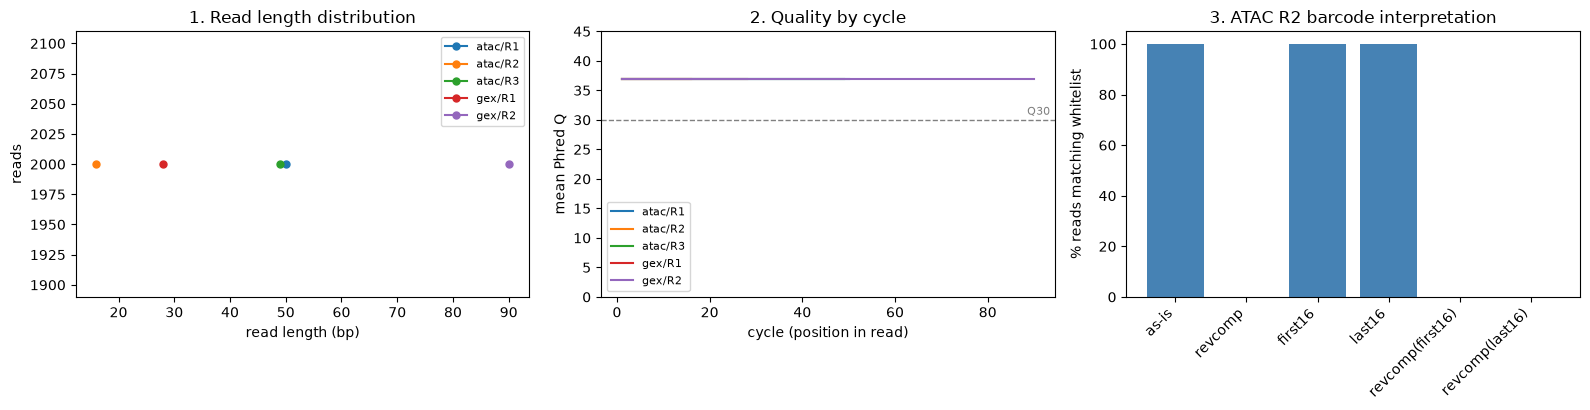

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))

# --- 1. read length distributions ---------------------------------------------
ax = axes[0]
for f in sorted(DATA_DIR.rglob("*.fastq.gz")):
    s = fastq_stats(f, 2000)
    lens = sorted(s["_lengths"])
    counts = [s["_lengths"][x] for x in lens]
    ax.plot(lens, counts, marker="o", ms=5, label=f"{f.parent.name}/{parse_fastq_name(f)['read']}")
ax.set(xlabel="read length (bp)", ylabel="reads", title="1. Read length distribution")
ax.legend(fontsize=8)

# --- 2. per-cycle quality ------------------------------------------------------
ax = axes[1]
for f in sorted(DATA_DIR.rglob("*.fastq.gz")):
    s = fastq_stats(f, 2000)
    q = np.array([x for x in s["_quals"] if len(x) == s["modal_len"]])
    ax.plot(np.arange(1, q.shape[1] + 1), q.mean(axis=0),
            label=f"{f.parent.name}/{parse_fastq_name(f)['read']}")
ax.axhline(30, ls="--", c="grey", lw=1)
ax.text(0.99, 30.4, "Q30", ha="right", va="bottom", color="grey", fontsize=8,
        transform=ax.get_yaxis_transform())
ax.set(xlabel="cycle (position in read)", ylabel="mean Phred Q",
       title="2. Quality by cycle", ylim=(0, 45))
ax.legend(fontsize=8)

# --- 3. barcode match rates ----------------------------------------------------
ax = axes[2]
atac_r2 = DATA_DIR / "atac" / "newt_atac_S1_L001_R2_001.fastq.gz"
rates = barcode_match_rates(atac_r2, ATAC_SET, 2000)
ax.bar(list(rates), [v * 100 for v in rates.values()], color="steelblue")
ax.set(ylabel="% reads matching whitelist", title="3. ATAC R2 barcode interpretation", ylim=(0, 105))
ax.tick_params(axis="x", rotation=45)
for lbl in ax.get_xticklabels():
    lbl.set_ha("right")

plt.tight_layout()
plt.show()

## 9. Writing `libraries.csv`

Once the FASTQs pass, the run itself is configured by a three-column CSV. From
`cellranger-arc count --help`:

```
fastqs,sample,library_type
/data/HAWT7ADXX/outs/fastq_path,myATAC,Chromatin Accessibility
/data/H35KCBCXY/outs/fastq_path,myGEX,Gene Expression
```

The details that bite:

* Column names and `library_type` values are **case-sensitive**. It is
  `Chromatin Accessibility`, not `chromatin accessibility` or `ATAC`.
* `fastqs` must be an **absolute directory path**. Not a file, not a glob, not a
  comma-separated list.
* Multiple flowcells or lanes for the same library go in as **extra rows** with the same
  `sample` and `library_type`.
* Blank lines are ignored, so trailing newlines are harmless.

In [12]:
def write_libraries_csv(dest: Path, entries: list[tuple[Path, str, str]]) -> Path:
    """entries: list of (fastq_dir, sample, library_type). Validates before writing."""
    valid_types = {"Gene Expression", "Chromatin Accessibility"}
    lines = ["fastqs,sample,library_type"]
    for fq_dir, sample, lib_type in entries:
        fq_dir = Path(fq_dir).resolve()
        if lib_type not in valid_types:
            raise ValueError(f"library_type must be one of {valid_types}, got {lib_type!r}")
        if not fq_dir.is_dir():
            raise NotADirectoryError(f"{fq_dir} is not a directory")
        found = [f for f in fq_dir.glob("*.fastq.gz")
                 if (p := parse_fastq_name(f)) and p["sample"] == sample]
        if not found:
            raise FileNotFoundError(
                f"no FASTQs in {fq_dir} with sample prefix {sample!r} -- "
                f"present: {sorted(f.name for f in fq_dir.glob('*.fastq.gz'))}"
            )
        lines.append(f"{fq_dir},{sample},{lib_type}")
    dest.parent.mkdir(parents=True, exist_ok=True)
    dest.write_text("\n".join(lines) + "\n")
    return dest

libs = write_libraries_csv(
    PROJECT / "run" / "libraries_demo.csv",
    [
        (DATA_DIR / "gex", "newt_gex", "Gene Expression"),
        (DATA_DIR / "atac", "newt_atac", "Chromatin Accessibility"),
    ],
)
print(libs.read_text())

fastqs,sample,library_type
/home/supermepsipax/Code/cellranger/data/demo/gex,newt_gex,Gene Expression
/home/supermepsipax/Code/cellranger/data/demo/atac,newt_atac,Chromatin Accessibility



## 10. One function to validate a delivery — and what comes next

`preflight()` bundles §§3, 5, 6 and 7 into a single call. Point it at a directory and a
library type and it tells you whether Cell Ranger ARC will accept it.

In [13]:
def preflight(directory: Path, library_type: str, limit: int = 5000) -> bool:
    """Run every check in this notebook against one library directory."""
    directory = Path(directory)
    spec = SPECS[library_type]
    whitelist = GEX_SET if library_type == "Gene Expression" else ATAC_SET
    bc_read = "R1" if library_type == "Gene Expression" else "R2"
    problems: list[str] = []

    print(f"\n{'=' * 66}\nPREFLIGHT: {directory}  [{library_type}]\n{'=' * 66}")

    files = sorted(directory.glob("*.fastq.gz"))
    if not files:
        print("  FAIL  no .fastq.gz files found")
        return False

    # -- naming ---------------------------------------------------------------
    parsed = {f: parse_fastq_name(f) for f in files}
    bad = [f.name for f, p in parsed.items() if p is None]
    if bad:
        problems.append(f"filenames do not match the bcl2fastq pattern: {bad}")
    ok = {f: p for f, p in parsed.items() if p}
    samples = {p["sample"] for p in ok.values()}
    if len(samples) > 1:
        problems.append(f"multiple sample prefixes in one directory: {sorted(samples)}")

    # -- completeness ---------------------------------------------------------
    present = {p["read"] for p in ok.values()}
    missing = {r for r, s in spec.items() if s.required} - present
    if missing:
        problems.append(f"missing required reads: {sorted(missing)}")

    # -- lengths --------------------------------------------------------------
    for f, p in ok.items():
        exp = spec.get(p["read"])
        if exp is None:
            continue
        obs = fastq_stats(f, limit)["modal_len"]
        if obs < exp.length and p["read"] in {"R1", "R2"} and exp.length <= 28:
            problems.append(f"{f.name}: {p['read']} is {obs} bp, spec requires {exp.length} bp "
                            "(barcode/UMI reads cannot be short) -- not repairable")
        elif obs != exp.length:
            print(f"  note  {f.name}: {p['read']} is {obs} bp vs spec {exp.length} bp")

    # -- barcodes -------------------------------------------------------------
    bc_files = [f for f, p in ok.items() if p["read"] == bc_read]
    if not bc_files:
        problems.append(f"no {bc_read} file, so barcodes cannot be checked")
    for f in bc_files:
        rates = barcode_match_rates(f, whitelist, limit)
        expected = EXPECTED_INTERP[library_type]
        got = rates[expected]
        best, best_rate = max(rates.items(), key=lambda kv: kv[1])
        print(f"  barcode  {f.name}: {expected!r} (expected) = {got:.1%}; "
              f"best = {best!r} at {best_rate:.1%}")
        if got >= 0.50:
            pass                                    # barcode is where the pipeline expects it
        elif best_rate >= 0.50:
            problems.append(f"{f.name}: barcodes are present but only as {best!r}, "
                            f"not the expected {expected!r} -- transform this file "
                            "before running the pipeline")
        else:
            problems.append(f"{f.name}: no interpretation matches the {library_type} whitelist "
                            f"(best {best!r} = {best_rate:.1%}) -- wrong read, wrong whitelist, "
                            "or wrong orientation")

    if problems:
        print("\n  RESULT: NOT READY")
        for p in problems:
            print(f"    - {p}")
        return False
    print("\n  RESULT: READY")
    return True

preflight(DATA_DIR / "gex", "Gene Expression")
preflight(DATA_DIR / "atac", "Chromatin Accessibility")
preflight(broken / "atac", "Chromatin Accessibility")   # expected to fail


PREFLIGHT: /home/supermepsipax/Code/cellranger/data/demo/gex  [Gene Expression]
  barcode  newt_gex_S1_L001_R1_001.fastq.gz: 'first16' (expected) = 100.0%; best = 'first16' at 100.0%

  RESULT: READY

PREFLIGHT: /home/supermepsipax/Code/cellranger/data/demo/atac  [Chromatin Accessibility]
  barcode  newt_atac_S1_L001_R2_001.fastq.gz: 'as-is' (expected) = 100.0%; best = 'as-is' at 100.0%

  RESULT: READY

PREFLIGHT: /home/supermepsipax/Code/cellranger/data/demo_broken/atac  [Chromatin Accessibility]
  note  newt_atac_S1_L001_R2_001.fastq.gz: R2 is 24 bp vs spec 16 bp
  barcode  newt_atac_S1_L001_R2_001.fastq.gz: 'as-is' (expected) = 0.0%; best = 'first16' at 100.0%

  RESULT: NOT READY
    - newt_atac_S1_L001_R2_001.fastq.gz: barcodes are present but only as 'first16', not the expected 'as-is' -- transform this file before running the pipeline


False

### When your drive is mounted

1. Set `DATA_DIR` in the config cell to the real path and re-run.
2. Run `preflight()` on each library directory. Fix what it reports, using `trim_fastq()`
   or a rename as appropriate.
3. Regenerate `libraries.csv` with the real paths via `write_libraries_csv()`.

### Then: the reference

`cellranger-arc count` needs `--reference`, and no pre-built newt reference exists, so you
will build one with `cellranger-arc mkref` from your genome FASTA + GTF. Be aware this is
the genuinely hard part of the project rather than a formality:

* Salamander genomes are enormous — often 20–30 Gb, roughly ten times human. `mkref` builds
  a STAR index, whose memory requirement scales with genome size, and the standard advice of
  "64 GB RAM" is calibrated for human. Check what your laptop has before starting; this step
  may need a cluster or a high-memory cloud instance.
* `mkref` is strict about GTF structure. It needs `gene_id`, `transcript_id` and `exon`
  features, and many amphibian annotations are lighter than that. `cellranger-arc mkgtf`
  filters an existing GTF; it cannot invent missing attributes.
* ATAC additionally wants contig/chromosome definitions in the reference config.

### Finally: the run

```bash
cellranger-arc count \
  --id=newt_run1 \
  --reference=/path/to/refdata-newt-arc \
  --libraries=/home/supermepsipax/Code/cellranger/run/libraries.csv \
  --create-bam=false \
  --localcores=8 \
  --localmem=48
```

Before committing to a real run, verify the install end to end with
`cellranger-arc testrun --id=tiny` — it runs a miniature pipeline on bundled data and takes
about an hour.

### Sources

* [Analyzing GEX and ATAC Libraries with Cell Ranger ARC](https://www.10xgenomics.com/support/software/cell-ranger-arc/latest/analysis/running-pipelines/single-library-analysis)
* [Specifying Input FASTQ Files for cellranger-arc count](https://www.10xgenomics.com/support/software/cell-ranger-arc/latest/analysis/inputs/specifying-input-fastq-count)
* [Sequencing Requirements for Single Cell Multiome ATAC + Gene Expression](https://www.10xgenomics.com/support/epi-multiome/documentation/steps/sequencing/sequencing-requirements-for-single-cell-multiome-atac-plus-gene-expression)